In [1]:
import pandas as pd
!pip install catboost
df = pd.read_csv('/content/waterQuality1.csv')
df.head()
model_roc_data = {}
model_cm_data = {}
model_acc_data={}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


In [2]:
print("DataFrame Info:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDescriptive statistics for numerical columns:")
print(df.describe())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7999 entries, 0 to 7998
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7999 non-null   float64
 1   ammonia      7999 non-null   object 
 2   arsenic      7999 non-null   float64
 3   barium       7999 non-null   float64
 4   cadmium      7999 non-null   float64
 5   chloramine   7999 non-null   float64
 6   chromium     7999 non-null   float64
 7   copper       7999 non-null   float64
 8   flouride     7999 non-null   float64
 9   bacteria     7999 non-null   float64
 10  viruses      7999 non-null   float64
 11  lead         7999 non-null   float64
 12  nitrates     7999 non-null   float64
 13  nitrites     7999 non-null   float64
 14  mercury      7999 non-null   float64
 15  perchlorate  7999 non-null   float64
 16  radium       7999 non-null   float64
 17  selenium     7999 non-null   float64
 18  silver       7999 non-null   flo

In [3]:
print("Original data types for 'ammonia' and 'is_safe':")
print(df[['ammonia', 'is_safe']].dtypes)

# Convert 'ammonia' to numeric, coercing errors to NaN
df['ammonia'] = pd.to_numeric(df['ammonia'], errors='coerce')

# Convert 'is_safe' to numeric, coercing errors to NaN
df['is_safe'] = pd.to_numeric(df['is_safe'], errors='coerce')

# Check for any new NaNs introduced in 'ammonia' or 'is_safe' after conversion
print("\nMissing values after converting 'ammonia' and 'is_safe' to numeric:")
print(df[['ammonia', 'is_safe']].isnull().sum())

# Handle any NaNs introduced in 'ammonia' by filling with the mean/median, or dropping rows. For now, fill with mean.
# Assuming 'ammonia' is a continuous variable
if df['ammonia'].isnull().any():
    ammonia_nan_count = df['ammonia'].isnull().sum()
    print(f"\n{ammonia_nan_count} NaN values found in 'ammonia'. Filling with mean.")
    df['ammonia'] = df['ammonia'].fillna(df['ammonia'].mean())

# Handle any NaNs introduced in 'is_safe' (if any non-numeric values existed), likely by dropping or mode imputation
# Given 'is_safe' is a target variable, dropping rows with NaN might be appropriate if there are few.
# If there are many, further investigation is needed.
if df['is_safe'].isnull().any():
    is_safe_nan_count = df['is_safe'].isnull().sum()
    print(f"\n{is_safe_nan_count} NaN values found in 'is_safe'. This is unexpected for a target variable. Investigating unique values:")
    print(df[df['is_safe'].isnull()]['is_safe'].unique())
    # For this task, assuming 'is_safe' should only be 0 or 1, and any coerced NaNs are errors.
    # Let's drop rows where 'is_safe' is NaN if they exist. Or, if it's due to a single 'unknown' value, we can drop those.
    # Based on the task description, 'is_safe' is likely the target, so we want it clean.
    df.dropna(subset=['is_safe'], inplace=True)
    print("Rows with NaN in 'is_safe' dropped.")

# Convert 'is_safe' to integer type as it represents a binary classification target
df['is_safe'] = df['is_safe'].astype(int)

print("\nUpdated data types for 'ammonia' and 'is_safe':")
print(df[['ammonia', 'is_safe']].dtypes)

print("\nUnique values in 'is_safe' after conversion:")
print(df['is_safe'].unique())


Original data types for 'ammonia' and 'is_safe':
ammonia    object
is_safe    object
dtype: object

Missing values after converting 'ammonia' and 'is_safe' to numeric:
ammonia    3
is_safe    3
dtype: int64

3 NaN values found in 'ammonia'. Filling with mean.

3 NaN values found in 'is_safe'. This is unexpected for a target variable. Investigating unique values:
[nan]
Rows with NaN in 'is_safe' dropped.

Updated data types for 'ammonia' and 'is_safe':
ammonia    float64
is_safe      int64
dtype: object

Unique values in 'is_safe' after conversion:
[1 0]


In [4]:
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Separate features (X) from the target variable (y)
X = df.drop('is_safe', axis=1)
y = df['is_safe']

# 2. Initialize SelectKBest with f_classif and k=6
selector = SelectKBest(score_func=f_classif, k=6)

# 3. Fit the SelectKBest model to your features (X) and target (y)
selector.fit(X, y)

# 4. Get the indices of the selected features
selected_feature_indices = selector.get_support(indices=True)

# 5. Use these indices to retrieve the names of the top 6 features
selected_features = X.columns[selected_feature_indices].tolist()

# 6. Print the list of the top 6 selected features
print(f"Top 6 selected features: {selected_features}")

Top 6 selected features: ['aluminium', 'arsenic', 'cadmium', 'chloramine', 'chromium', 'silver']


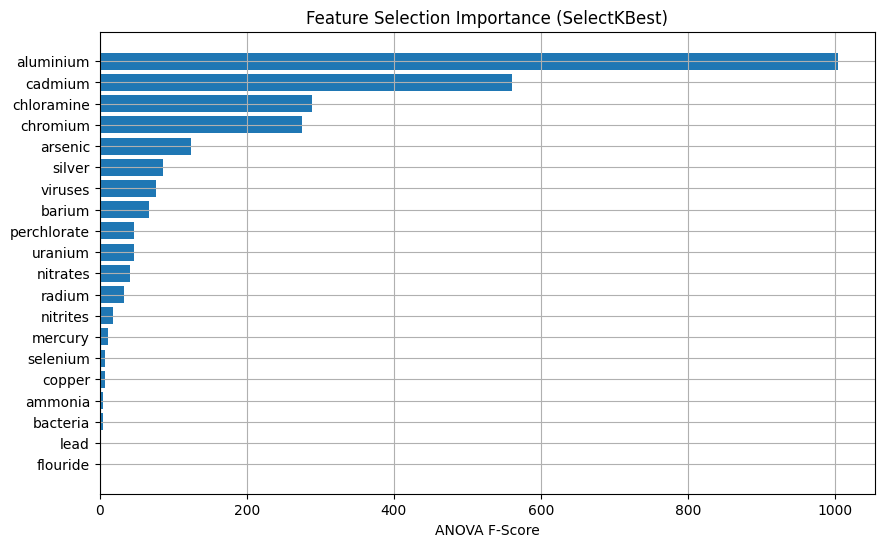

Selected Top Features: ['aluminium', 'arsenic', 'cadmium', 'chloramine', 'chromium', 'silver']


In [5]:
# ==============================
# Feature Selection Importance Plot (SelectKBest)
# ==============================
import matplotlib.pyplot as plt
import pandas as pd

feature_scores = selector.scores_
feature_names = X.columns

fs_df = pd.DataFrame({
    'Feature': feature_names,
    'Score': feature_scores
}).sort_values(by='Score', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(fs_df['Feature'], fs_df['Score'])
plt.xlabel("ANOVA F-Score")
plt.title("Feature Selection Importance (SelectKBest)")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

selected_features = X.columns[selected_feature_indices].tolist()
print("Selected Top Features:", selected_features)


Generating pair plot for selected features...


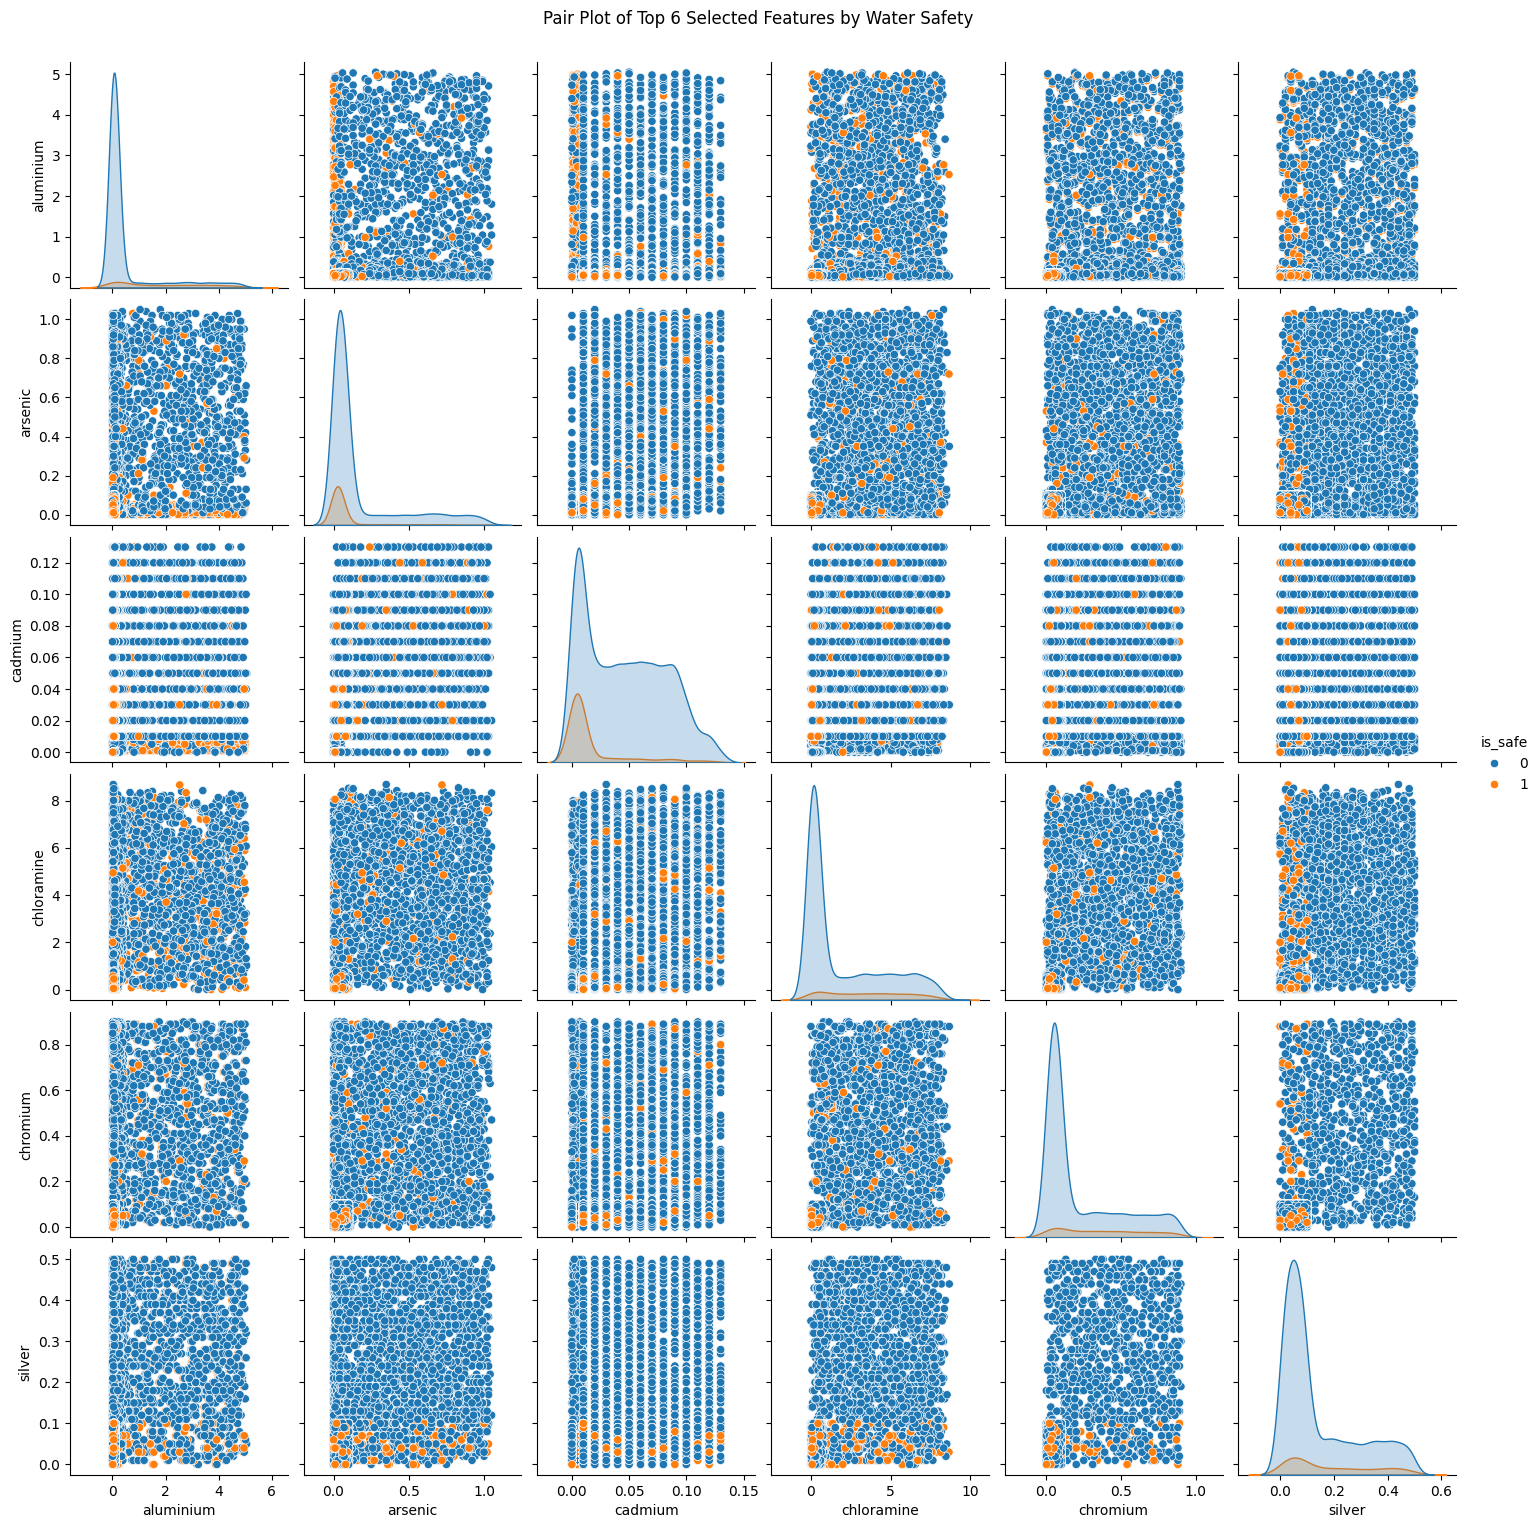

Pair plot generated.


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare the DataFrame with selected features and the target variable
df_selected = df[selected_features + ['is_safe']]

# Create a pair plot
# The 'hue' parameter will color the points based on the 'is_safe' column
print("Generating pair plot for selected features...")
sns.pairplot(df_selected, hue='is_safe', diag_kind='kde')
plt.suptitle('Pair Plot of Top 6 Selected Features by Water Safety', y=1.02) # Add a title to the plot
plt.show()
print("Pair plot generated.")

In [7]:
# ==============================
# LightGBM + ANN Hybrid Model (Using Selected Features)
# ==============================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Use only selected features
X_selected = df[selected_features]
y = df['is_safe']

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Feature Scaling (important for ANN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# Step 1: Train LightGBM Model
# ==============================
lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

lgbm_model.fit(X_train, y_train)

# Get LightGBM predictions as meta-features
lgbm_train_pred = lgbm_model.predict_proba(X_train)[:, 1].reshape(-1, 1)
lgbm_test_pred = lgbm_model.predict_proba(X_test)[:, 1].reshape(-1, 1)

# ==============================
# Step 2: Combine Features for ANN (Hybrid Input)
# ==============================
import numpy as np

X_train_hybrid = np.hstack((X_train_scaled, lgbm_train_pred))
X_test_hybrid = np.hstack((X_test_scaled, lgbm_test_pred))

# ==============================
# Step 3: Build ANN Model
# ==============================
ann_model = Sequential([
    Dense(64, activation='relu', input_dim=X_train_hybrid.shape[1]),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary classification (is_safe)
])

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==============================
# Step 4: Train ANN
# ==============================
history = ann_model.fit(
    X_train_hybrid, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# ==============================
# Step 5: Evaluation
# ==============================
y_pred_prob = ann_model.predict(X_test_hybrid)
y_pred = (y_pred_prob > 0.5).astype(int)

print("LightGBM + ANN Hybrid Model Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
model_roc_data['LIGHTGBM + ANN'] = {'y_test': y_test, 'y_pred_prob': y_pred}
model_cm_data['LIGHTGBM + ANN'] = confusion_matrix(y_test, y_pred)
model_acc_data['LIGHTGBM + ANN'] = accuracy_score(y_test, y_pred)


[LightGBM] [Info] Number of positive: 730, number of negative: 5666
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000859 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 774
[LightGBM] [Info] Number of data points in the train set: 6396, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.114134 -> initscore=-2.049194
[LightGBM] [Info] Start training from score -2.049194
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8768 - loss: 0.3548 - val_accuracy: 0.9125 - val_loss: 0.2303
Epoch 2/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9088 - loss: 0.2288 - val_accuracy: 0.9375 - val_loss: 0.1890
Epoch 3/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9326 - loss: 0.1836 - val_accuracy: 0.9484 - val_loss: 0.1661
Epoch 4/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9463 - loss: 0.1616 - val_accuracy: 0.9500 - val_loss: 0.1618
Epoch 5/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9509 - loss: 0.1483 - val_accuracy: 0.9516 - val_loss: 0.1500
Epoch 6/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9513 - loss: 0.1379 - val_accuracy: 0.9555 - val_loss: 0.1487
Epoch 7/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9533 - loss: 0.1426 - val_accuracy: 0.9516 - val_loss: 0.1449
Epoch 8/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9567 - loss: 0.1328 - val_acc

In [8]:
# ==============================
# XGBoost + ANN Hybrid Model (Using Selected Features)
# ==============================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import numpy as np

# 1. Use only selected features
X_selected = df[selected_features]
y = df['is_safe']   # change if your target column name is different

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scaling for ANN (important)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# Step 1: Train XGBoost Model (Expert Model)
# ==============================
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Get XGBoost probability predictions (meta-feature)
xgb_train_pred = xgb_model.predict_proba(X_train)[:, 1].reshape(-1, 1)
xgb_test_pred = xgb_model.predict_proba(X_test)[:, 1].reshape(-1, 1)

# ==============================
# Step 2: Create Hybrid Input (Features + XGBoost Output)
# ==============================
X_train_hybrid = np.hstack((X_train_scaled, xgb_train_pred))
X_test_hybrid = np.hstack((X_test_scaled, xgb_test_pred))

# ==============================
# Step 3: Build ANN Model
# ==============================
ann_model = Sequential([
    Dense(128, activation='relu', input_dim=X_train_hybrid.shape[1]),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==============================
# Step 4: Train ANN
# ==============================
history = ann_model.fit(
    X_train_hybrid, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# ==============================
# Step 5: Evaluation
# ==============================
y_pred_prob = ann_model.predict(X_test_hybrid)
y_pred = (y_pred_prob > 0.5).astype(int)

print("XGBoost + ANN Hybrid Model Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
model_roc_data['XGBoost + ANN'] = {'y_test': y_test, 'y_pred_prob': y_pred}
model_cm_data['XGBoost + ANN'] = confusion_matrix(y_test, y_pred)
model_acc_data['XGBoost + ANN'] = accuracy_score(y_test, y_pred)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8884 - loss: 0.3067 - val_accuracy: 0.9484 - val_loss: 0.1684
Epoch 2/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9424 - loss: 0.1742 - val_accuracy: 0.9547 - val_loss: 0.1450
Epoch 3/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9505 - loss: 0.1508 - val_accuracy: 0.9570 - val_loss: 0.1321
Epoch 4/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9589 - loss: 0.1274 - val_accuracy: 0.9594 - val_loss: 0.1279
Epoch 5/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9580 - loss: 0.1343 - val_accuracy: 0.9594 - val_loss: 0.1269
Epoch 6/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9589 - loss: 0.1356 - val_accuracy: 0.9563 - val_loss: 0.1217
Epoch 7/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9598 - loss: 0.1216 - val_accuracy: 0.9609 - val_loss: 0.1190
Epoch 8/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9652 - loss: 0.1055 - val_accuracy: 0.9617

In [9]:
# ==============================
# CatBoost + ANN Hybrid Model (Using Selected Features)
# ==============================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import numpy as np

# 1. Use only selected features
X_selected = df[selected_features]
y = df['is_safe']   # change if your target column name is different

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scaling for ANN (important)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# Step 1: Train CatBoost Model (Expert Model)
# ==============================
cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_state=42,
    verbose=0
)

cat_model.fit(X_train, y_train)

# Get CatBoost probability predictions (meta-feature)
cat_train_pred = cat_model.predict_proba(X_train)[:, 1].reshape(-1, 1)
cat_test_pred = cat_model.predict_proba(X_test)[:, 1].reshape(-1, 1)

# ==============================
# Step 2: Create Hybrid Input (Features + CatBoost Output)
# ==============================
X_train_hybrid = np.hstack((X_train_scaled, cat_train_pred))
X_test_hybrid = np.hstack((X_test_scaled, cat_test_pred))

# ==============================
# Step 3: Build ANN Model
# ==============================
ann_model = Sequential([
    Dense(128, activation='relu', input_dim=X_train_hybrid.shape[1]),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==============================
# Step 4: Train ANN
# ==============================
history = ann_model.fit(
    X_train_hybrid, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# ==============================
# Step 5: Evaluation
# ==============================
y_pred_prob = ann_model.predict(X_test_hybrid)
y_pred = (y_pred_prob > 0.5).astype(int)

print("CatBoost + ANN Hybrid Model Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
model_roc_data['CatBoost + ANN'] = {'y_test': y_test, 'y_pred_prob': y_pred}
model_cm_data['CatBoost + ANN'] = confusion_matrix(y_test, y_pred)
model_acc_data['CatBoost + ANN'] = accuracy_score(y_test, y_pred)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8741 - loss: 0.3348 - val_accuracy: 0.9367 - val_loss: 0.1905
Epoch 2/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9363 - loss: 0.1836 - val_accuracy: 0.9461 - val_loss: 0.1674
Epoch 3/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9405 - loss: 0.1721 - val_accuracy: 0.9469 - val_loss: 0.1611
Epoch 4/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9504 - loss: 0.1540 - val_accuracy: 0.9539 - val_loss: 0.1527
Epoch 5/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9503 - loss: 0.1604 - val_accuracy: 0.9570 - val_loss: 0.1500
Epoch 6/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9490 - loss: 0.1558 - val_accuracy: 0.9531 - val_loss: 0.1490
Epoch 7/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9581 - loss: 0.1342 - val_accuracy: 0.9547 - val_loss: 0.1415
Epoch 8/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9552 - loss: 0.1404 - val_accuracy: 0.9555

In [10]:
# ==============================
# AdaBoost + ANN Hybrid Model (Using Selected Features)
# ==============================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import numpy as np

# 1. Use only selected features
X_selected = df[selected_features]
y = df['is_safe']   # change if your target column name is different

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scaling for ANN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# Step 1: Train AdaBoost Model (Expert)
# ==============================
base_estimator = DecisionTreeClassifier(max_depth=2, random_state=42)

ada_model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

ada_model.fit(X_train, y_train)

# Get AdaBoost probability predictions (meta-feature)
ada_train_pred = ada_model.predict_proba(X_train)[:, 1].reshape(-1, 1)
ada_test_pred = ada_model.predict_proba(X_test)[:, 1].reshape(-1, 1)

# ==============================
# Step 2: Create Hybrid Input (Features + AdaBoost Output)
# ==============================
X_train_hybrid = np.hstack((X_train_scaled, ada_train_pred))
X_test_hybrid = np.hstack((X_test_scaled, ada_test_pred))

# ==============================
# Step 3: Build ANN Model
# ==============================
ann_model = Sequential([
    Dense(128, activation='relu', input_dim=X_train_hybrid.shape[1]),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==============================
# Step 4: Train ANN
# ==============================
history = ann_model.fit(
    X_train_hybrid, y_train,
    epochs=80,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# ==============================
# Step 5: Evaluation
# ==============================
y_pred_prob = ann_model.predict(X_test_hybrid)
y_pred = (y_pred_prob > 0.5).astype(int)

print("AdaBoost + ANN Hybrid Model Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
model_roc_data['AdaBoost + ANN'] = {'y_test': y_test, 'y_pred_prob': y_pred}
model_cm_data['AdaBoost + ANN'] = confusion_matrix(y_test, y_pred)
model_acc_data['AdaBoost + ANN'] = accuracy_score(y_test, y_pred)

Epoch 1/80


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8661 - loss: 0.3565 - val_accuracy: 0.9086 - val_loss: 0.2528
Epoch 2/80
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9076 - loss: 0.2358 - val_accuracy: 0.9164 - val_loss: 0.2335
Epoch 3/80
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9088 - loss: 0.2303 - val_accuracy: 0.9164 - val_loss: 0.2250
Epoch 4/80
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9090 - loss: 0.2237 - val_accuracy: 0.9211 - val_loss: 0.2244
Epoch 5/80
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9134 - loss: 0.2266 - val_accuracy: 0.9234 - val_loss: 0.2245
Epoch 6/80
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9060 - loss: 0.2193 - val_accuracy: 0.9234 - val_loss: 0.2171
Epoch 7/80
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9154 - loss: 0.2156 - val_accuracy: 0.9203 - val_loss: 0.2169
Epoch 8/80
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9162 - loss: 0.2066 - val_accuracy: 0.9211 - val_

# *LIGHTGBM+LSTM*

In [11]:
# ==============================
# LightGBM + LSTM Hybrid Model
# Using Selected Features Only
# ==============================

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from lightgbm import LGBMClassifier

# 1. Use selected features
X = df[selected_features].values
y = df['is_safe'].values   # change if target column name differs

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scaling (important for LSTM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# STEP 1: Train LightGBM (Expert Model)
# ==============================
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_model.fit(X_train, y_train)

# LightGBM probability outputs (meta-feature)
lgbm_train_prob = lgbm_model.predict_proba(X_train)[:, 1].reshape(-1, 1)
lgbm_test_prob = lgbm_model.predict_proba(X_test)[:, 1].reshape(-1, 1)

# ==============================
# STEP 2: Create Hybrid Input (Features + LightGBM Output)
# ==============================
X_train_hybrid = np.hstack((X_train_scaled, lgbm_train_prob))
X_test_hybrid = np.hstack((X_test_scaled, lgbm_test_prob))

# Reshape for LSTM: (samples, timesteps, features)
# Treat each feature as a timestep (common tabular adaptation)
timesteps = X_train_hybrid.shape[1]
X_train_lstm = X_train_hybrid.reshape((X_train_hybrid.shape[0], timesteps, 1))
X_test_lstm = X_test_hybrid.reshape((X_test_hybrid.shape[0], timesteps, 1))

# ==============================
# STEP 3: Build LSTM Model (Meta Learner)
# ==============================
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(timesteps, 1)),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

# ==============================
# STEP 4: Train LSTM Hybrid Model
# ==============================
history = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# ==============================
# STEP 5: Evaluation
# ==============================
y_pred_prob = lstm_model.predict(X_test_lstm)
y_pred = (y_pred_prob > 0.5).astype(int)

print("LightGBM + LSTM Hybrid Model Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
model_roc_data['LIGHTGBM + LSTM'] = {'y_test': y_test, 'y_pred_prob': y_pred}
model_cm_data['LIGHTGBM + LSTM'] = confusion_matrix(y_test, y_pred)
model_acc_data['LIGHTGBM + LSTM'] = accuracy_score(y_test, y_pred)


[LightGBM] [Info] Number of positive: 730, number of negative: 5666
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000583 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 774
[LightGBM] [Info] Number of data points in the train set: 6396, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.114134 -> initscore=-2.049194
[LightGBM] [Info] Start training from score -2.049194
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8735 - loss: 0.4083 - val_accuracy: 0.8969 - val_loss: 0.2844
Epoch 2/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8897 - loss: 0.2937 - val_accuracy: 0.9094 - val_loss: 0.2648
Epoch 3/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8994 - loss: 0.2710 - val_accuracy: 0.9156 - val_loss: 0.2489
Epoch 4/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9052 - loss: 0.2580 - val_accuracy: 0.9156 - val_loss: 0.2416
Epoch 5/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9102 - loss: 0.2442 - val_accuracy: 0.9187 - val_loss: 0.2369
Epoch 6/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9134 - loss: 0.2387 - val_accuracy: 0.9203 - val_loss: 0.2271
Epoch 7/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9126 - loss: 0.2191 - val_accuracy: 0.9148 - val_loss: 0.2189
Epoch 8/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9122 - loss: 0.2165 - val

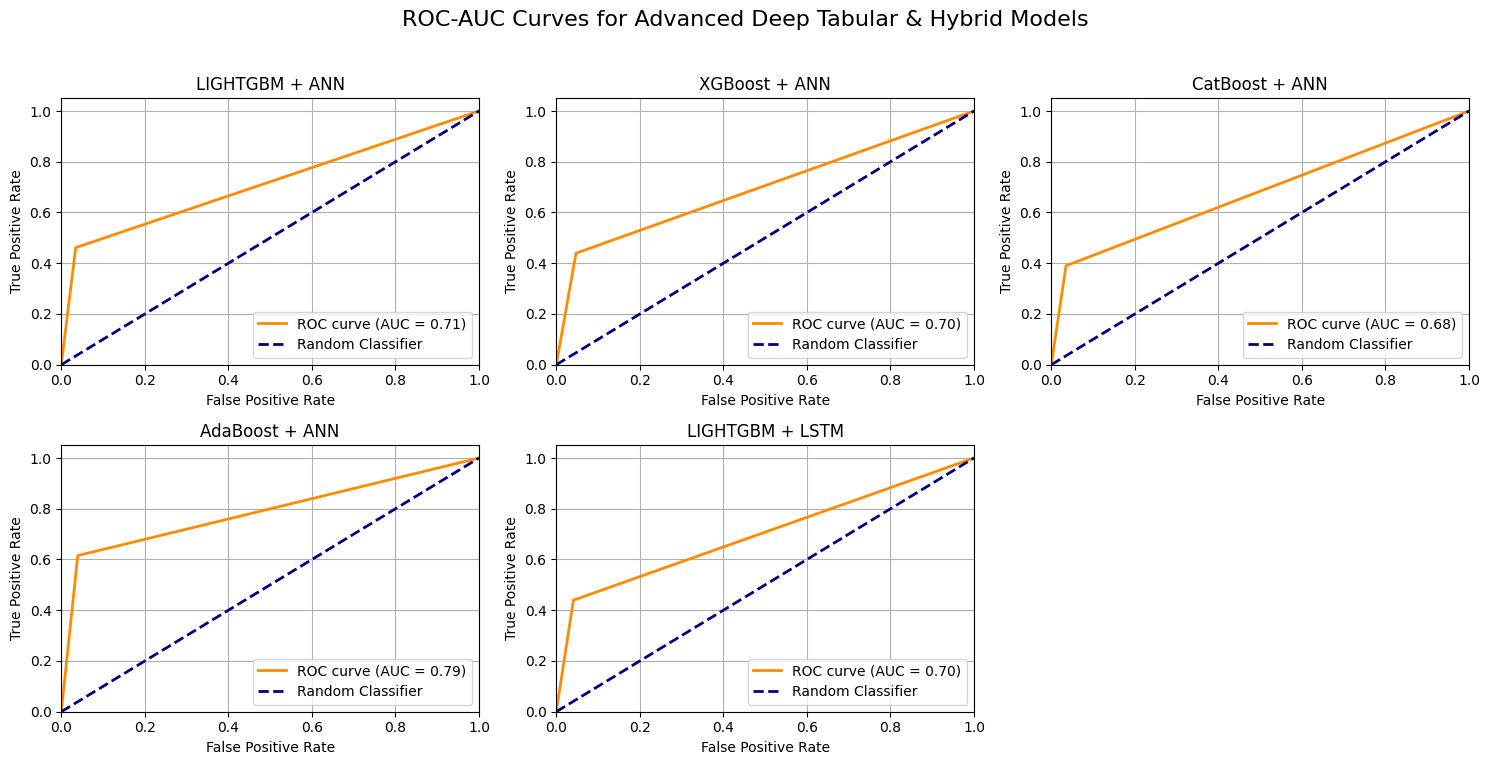

In [12]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import math

# Determine the number of models to plot
num_models = len(model_roc_data)
# Calculate the number of rows and columns for the subplots
num_cols = 3
num_rows = math.ceil(num_models / num_cols)

# Create a figure and a set of subplots
plt.figure(figsize=(num_cols * 5, num_rows * 4))
plt.suptitle("ROC-AUC Curves for Advanced Deep Tabular & Hybrid Models", fontsize=16)

for i, (model_name, data) in enumerate(model_roc_data.items()):
    y_test = data['y_test']
    y_pred_prob = data['y_pred_prob']

    # Ensure y_test and y_pred_prob have consistent lengths
    if len(y_test) != len(y_pred_prob):
        print(f"Warning: Mismatched lengths for {model_name}. y_test length: {len(y_test)}, y_pred_prob length: {len(y_pred_prob)}")
        # Attempt to truncate or align if possible, or skip plotting for this model
        min_len = min(len(y_test), len(y_pred_prob))
        y_test = y_test[:min_len]
        y_pred_prob = y_pred_prob[:min_len]
        if min_len == 0:
            print(f"Skipping {model_name} due to zero length after alignment.")
            continue

    # Calculate FPR, TPR, and AUC
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    # Create a subplot for each model
    plt.subplot(num_rows, num_cols, i + 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name}')
    plt.legend(loc="lower right")
    plt.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent suptitle overlap
plt.show()

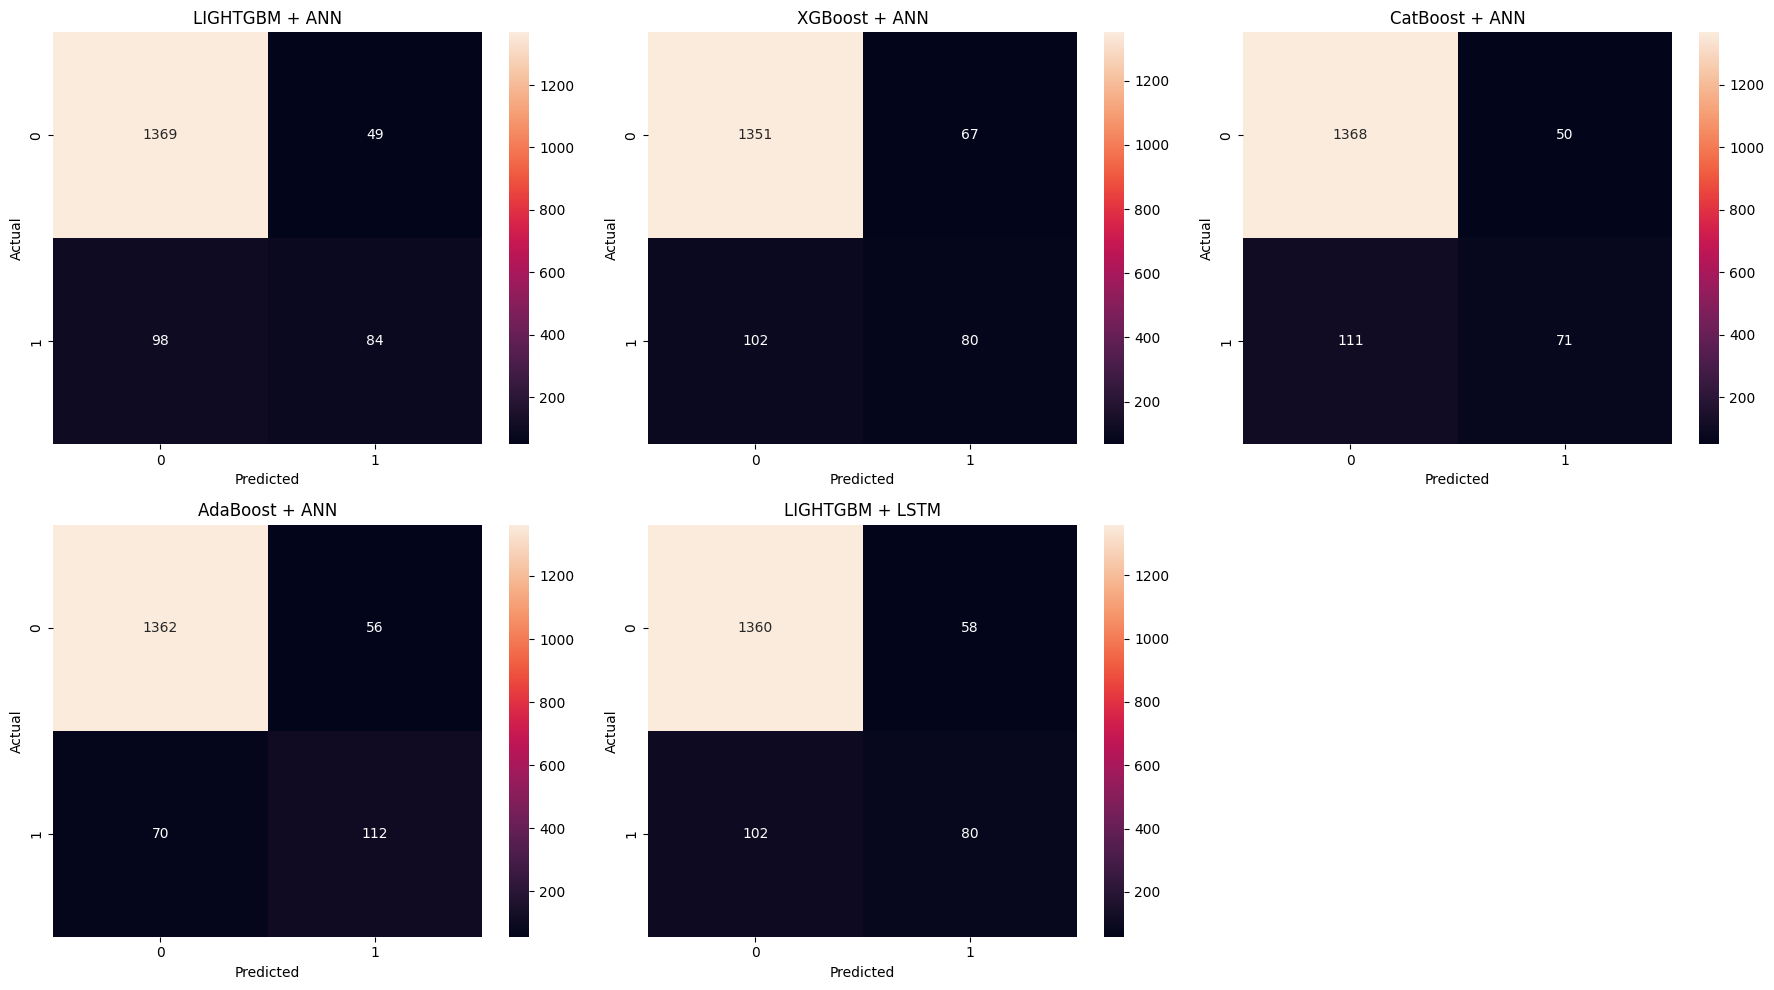

In [13]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt # Ensure matplotlib is imported for plotting

n_models = len(model_cm_data)
cols = 3
rows = (n_models // cols) + (n_models % cols > 0)

plt.figure(figsize=(18, 5 * rows))

for i, (name, cm_matrix) in enumerate(model_cm_data.items(), 1):
    # 'cm_matrix' already holds the confusion matrix, no need to re-compute it
    # The previous line 'current_y_test = model_roc_data[name.replace(' +ANN', ' + ANN')]['y_test']' is no longer needed
    cm = cm_matrix
    plt.subplot(rows, cols, i)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

/tmp/ipython-input-100375785.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=acc_df, palette='viridis')


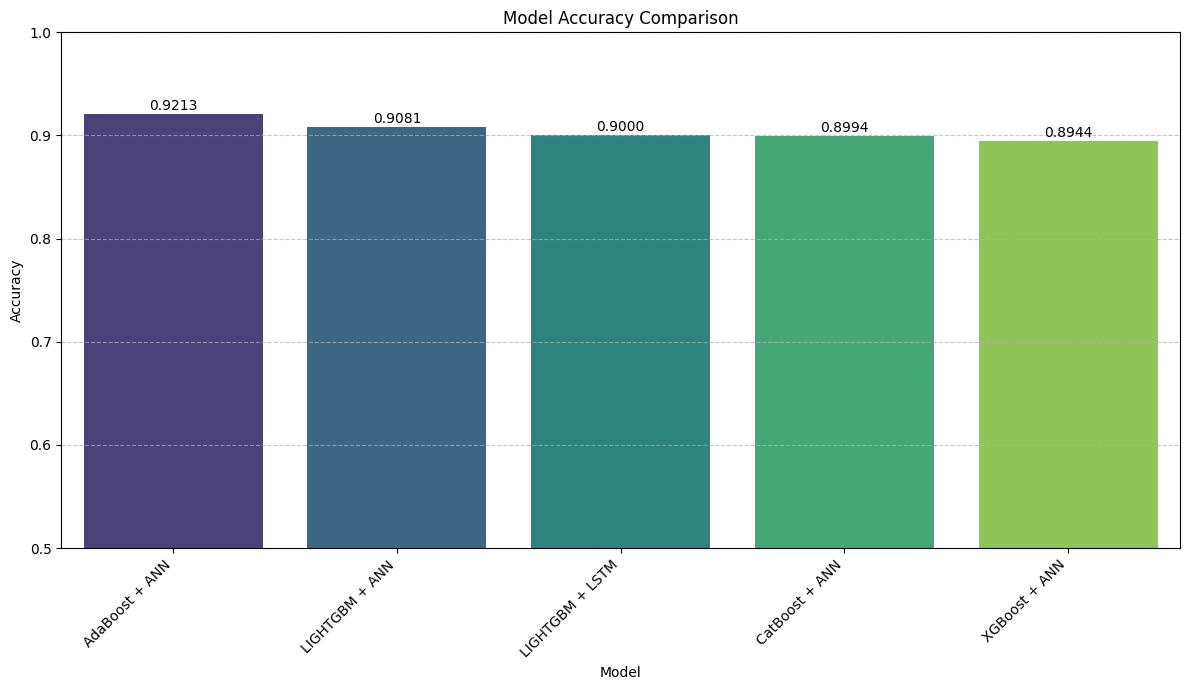

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Convert model_acc_data to a DataFrame for easier plotting
acc_df = pd.DataFrame(model_acc_data.items(), columns=['Model', 'Accuracy'])

# Sort by accuracy for better visualization
acc_df = acc_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(12, 7)) # Adjust figure size for vertical bars
sns.barplot(x='Model', y='Accuracy', data=acc_df, palette='viridis')
plt.ylabel('Accuracy') # Y-axis is now accuracy
plt.xlabel('Model')   # X-axis is now model names
plt.title('Model Accuracy Comparison')
plt.ylim(0.50, 1.0) # Set y-axis limit to focus on differences
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels if they overlap
for index, value in enumerate(acc_df['Accuracy']):
    plt.text(index, value + 0.001, f'{value:.4f}', ha='center', va='bottom') # Add accuracy values above bars
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()